# Analisi Statistica: Test del Chi Quadrato
In questo notebook analizziamo se la distribuzione dei flussi migratori registrata da **ISTAT** segue lo stesso andamento temporale dei dati **Eurostat** (paesi di destinazione).

**Ipotesi Nulla ($H_0$):** ISTAT segue la stessa distribuzione percentuale di Eurostat.
**Ipotesi Alternativa ($H_1$):** Esiste una differenza significativa nella distribuzione temporale.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from chi_square_test import MigrationChiSquareTest
import make_dataset

# Rigenerazione del dataset dai dati grezzi (data/raw/)
make_dataset.main()

# Inizializzazione suite con lista di alfa
alphas = [0.05, 0.01, 0.001]
tester = MigrationChiSquareTest("../data/merged_migration_data.csv", alphas=alphas)

# Caricamento risultati riassuntivi (include il TOTALE)
summary_df = tester.get_summary_df()
summary_df

Scanning raw data in c:\Users\FeN30\Desktop\report\data\raw...
Successfully merged 40 records into c:\Users\FeN30\Desktop\report\data\merged_migration_data.csv


,Entità,Chi2 Stat,p-value,Rifiuta H0 (α=0.05),Rifiuta H0 (α=0.01),Rifiuta H0 (α=0.001)
0,AT,66.960,0.000000,Sì,Sì,Sì
1,DE,691.664,0.000000,Sì,Sì,Sì
2,DK,170.624,0.000000,Sì,Sì,Sì
3,ES,1814.088,0.000000,Sì,Sì,Sì
4,FI,16.758,0.002154,Sì,Sì,No
5,FR,454.519,0.000000,Sì,Sì,Sì
6,NO,65.772,0.000000,Sì,Sì,Sì
7,SE,91.530,0.000000,Sì,Sì,Sì
8,TOTALE,3304.409,0.000000,Sì,Sì,Sì


## Visualizzazione Comparativa Globale e per Paese
In questa sezione visualizziamo il confronto tra i dati **ISTAT** (Osservati) e il modello **Eurostat** (Attesi). 
Il primo grafico mostra l'andamento aggregato (tutti i paesi), mentre la griglia successiva mostra il dettaglio per ogni singolo stato.

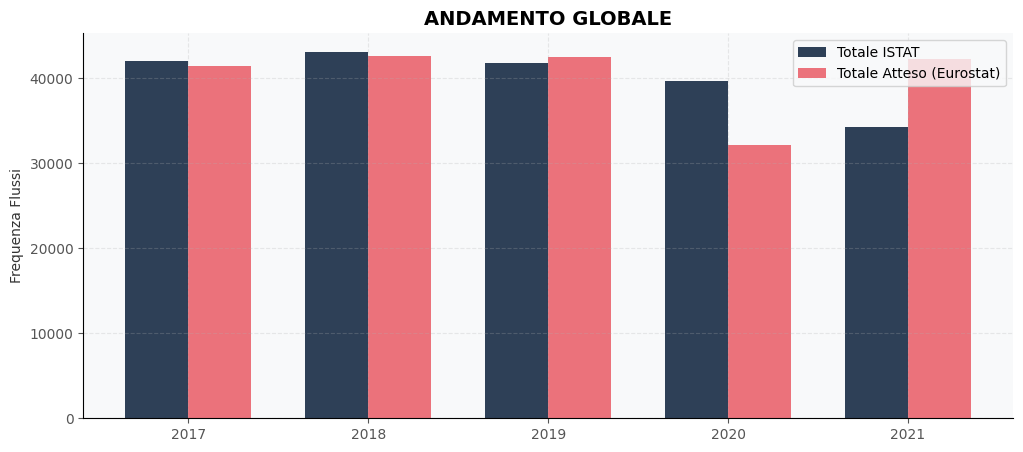

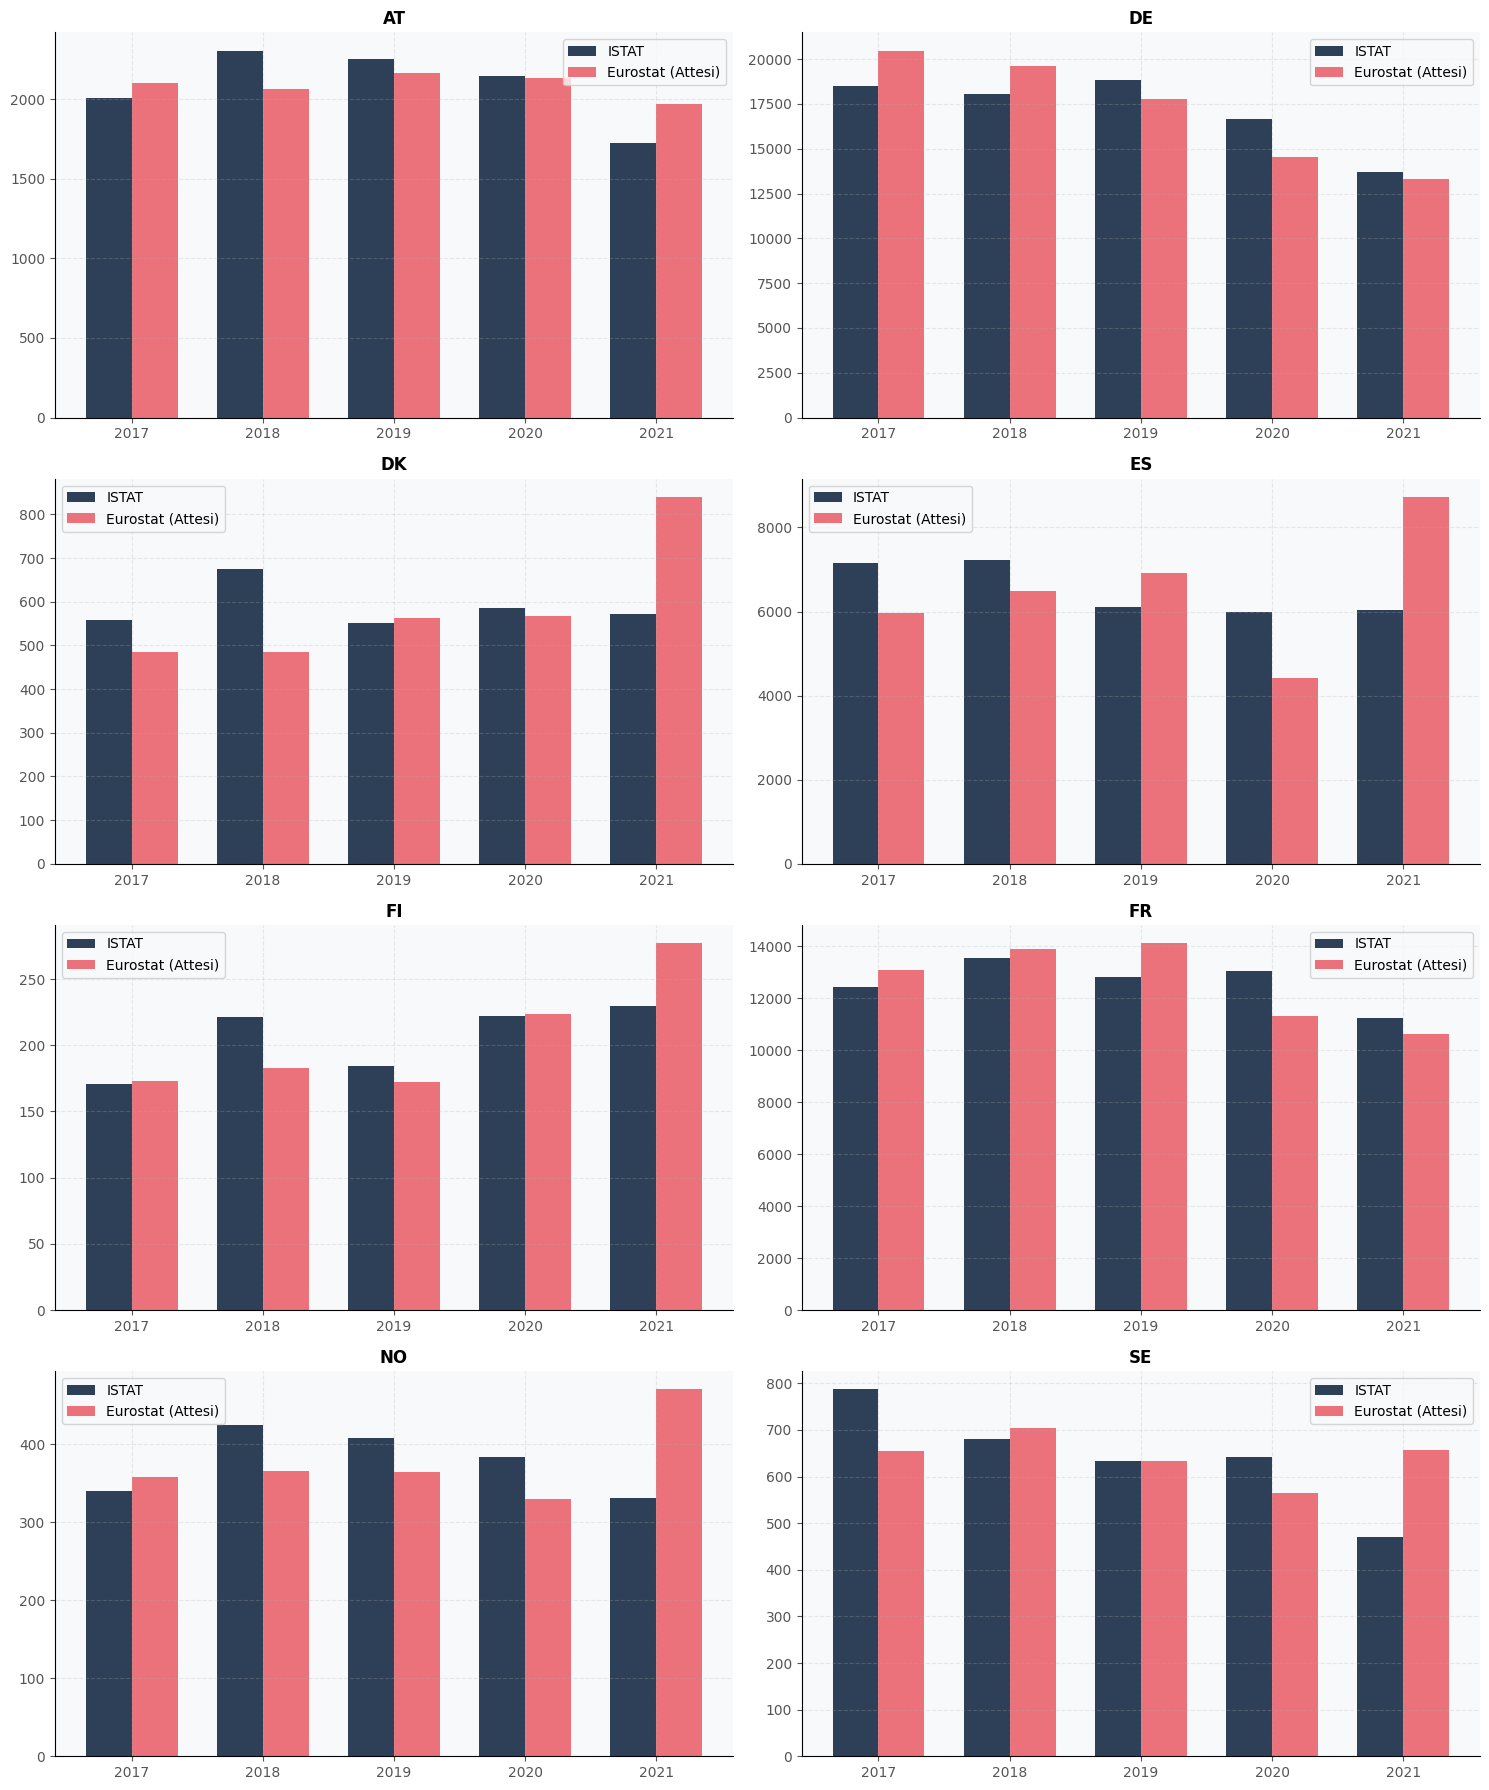

In [31]:
results = tester.test_all_countries()
countries_res = [r for r in results if r['label'] != "TOTALE"]
total_res = next(r for r in results if r['label'] == "TOTALE")
width = 0.35

# 1. Plot dei Flussi Totali (In alto, separato)
fig_tot, ax_tot = plt.subplots(figsize=(12, 5))
x_tot = np.arange(len(total_res['years']))

ax_tot.bar(x_tot - width/2, total_res['observed'], width, label='Totale ISTAT', color='#2e4057')
ax_tot.bar(x_tot + width/2, total_res['expected'], width, label='Totale Atteso (Eurostat)', color='#e63946', alpha=0.7)

ax_tot.set_ylabel('Frequenza Flussi')
ax_tot.set_title(f"ANDAMENTO GLOBALE", fontsize=14, fontweight='bold')
ax_tot.set_xticks(x_tot)
ax_tot.set_xticklabels(total_res['years'])
ax_tot.legend()
plt.show()

# 2. Griglia dei Paesi (4 righe x 2 colonne)
n_rows = 4
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 18))
axes = axes.flatten()

for i, r in enumerate(countries_res):
    ax = axes[i]
    x = np.arange(len(r['years']))
    
    ax.bar(x - width/2, r['observed'], width, label='ISTAT', color='#2e4057')
    ax.bar(x + width/2, r['expected'], width, label='Eurostat (Attesi)', color='#e63946', alpha=0.7)
    
    ax.set_title(f"{r['label']}", fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(r['years'])
    
    ax.legend()
plt.tight_layout()
plt.show()